In [14]:
from numpy import random
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import random
import torch.nn.functional as F
#Palabras a usar
palabras =["perro","Gato","avion","auto","pelota"]
vocab_size=len(palabras)#con esto contamos la cantidad de palabras
enbedding_dim=3#cada palabra se convierte en un vector de 3 números


In [9]:
#Embeddings
embeddings = nn.Embedding(num_embeddings=vocab_size, embedding_dim=enbedding_dim)
indices = torch.LongTensor([0, 1, 2, 3, 4])
vectores = embeddings(indices)
print(vectores)

tensor([[-0.9699, -0.0019, -0.6439],
        [ 0.7415,  0.8485, -0.5276],
        [ 0.2667, -0.4235,  0.0874],
        [-1.1426,  0.0160,  0.3264],
        [ 0.6641,  0.5051,  0.8603]], grad_fn=<EmbeddingBackward0>)


In [10]:
# Capa lineal para reducir a 2D y visualizar
capa_lineal = nn.Linear(enbedding_dim, 2)
print(capa_lineal)

Linear(in_features=3, out_features=2, bias=True)


In [11]:
vectores_2d = capa_lineal(vectores)
#Escalar los vectores para que no queden pegados
vectores_2d = vectores_2d * 5
print(vectores_2d)

tensor([[ 3.0066, -0.9936],
        [-1.3960,  4.5962],
        [ 1.3858,  1.4616],
        [ 3.2133, -1.0062],
        [-0.8312,  4.3288]], grad_fn=<MulBackward0>)


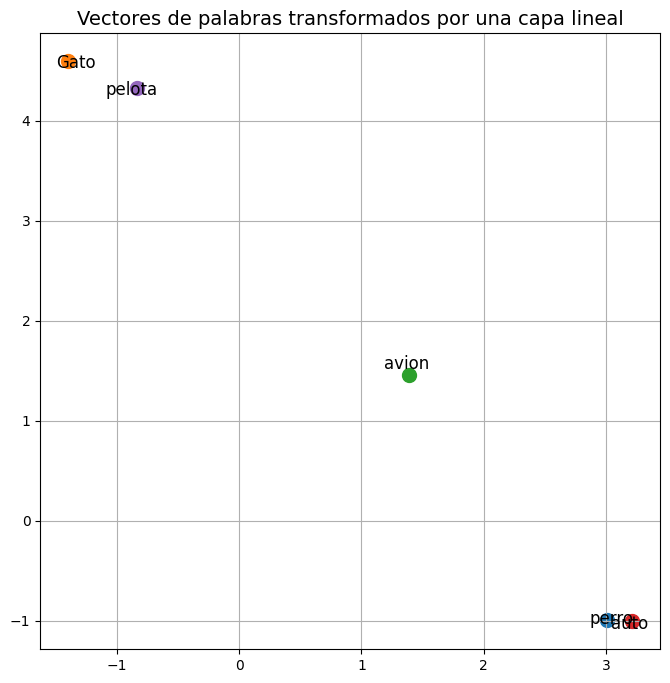

In [12]:
#Graficamos
plt.figure(figsize=(8,8))
for i, palabra in enumerate(palabras):
    x, y = vectores_2d[i].detach().numpy() # Apply .detach().numpy() here
    plt.scatter(x, y, s=100)  # puntos más grandes
    # Anotación con desplazamiento aleatorio para no superponer texto
    dx = random.uniform(-0.3, 0.3)
    dy = random.uniform(-0.3, 0.3)
    plt.annotate(palabra, (x, y), textcoords="offset points", xytext=(dx*20, dy*20), ha='center', fontsize=12)

plt.title("Vectores de palabras transformados por una capa lineal", fontsize=14)
plt.grid(True)
plt.show()

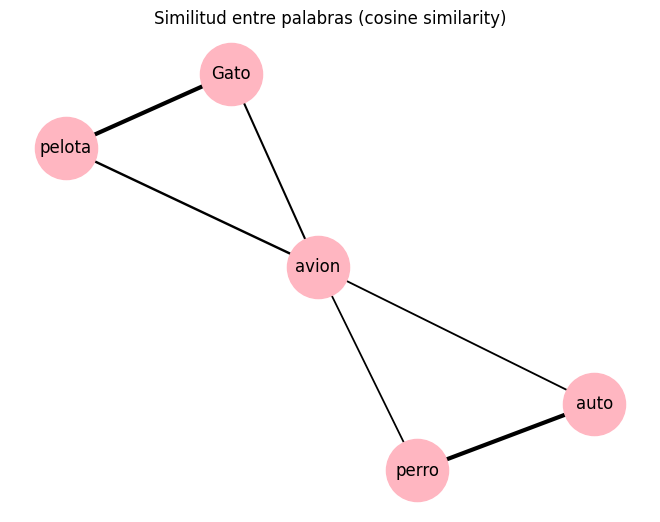

In [15]:

G = nx.Graph()
#encuentra similitud entre palabras usando coseno = producto punto / normas
for i in range(len(palabras)):
    for j in range(i+1, len(palabras)):
        sim = F.cosine_similarity(
            vectores_2d[i], vectores_2d[j], dim=0
        ).item()
        if sim > 0:  # solo conectar si son algo parecidas
            G.add_edge(palabras[i], palabras[j], weight=sim)
pos = nx.spring_layout(G)
weights = [G[u][v]['weight'] * 3 for u,v in G.edges]
nx.draw(G, pos, with_labels=True, node_color="lightpink",
        node_size=2000, width=weights)
plt.title("Similitud entre palabras (cosine similarity)")
plt.show()